# Reuters C50 - Klasifikacija autora novinskih tekstova
## 05 - Detaljna evaluacija modela

Detaljno analiziramo **SVM (LinearSVC)** kao globalno najboljeg modela:
confusion matrica, classification report, cross-validacija i analiza grešaka po autorima.

### Ćelija 1 - Uvoz i priprema (TF-IDF + SVM treniranje)

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

SLIKE_PATH   = '/home/zagorka/Desktop/ip2Projekat/slike'
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('/home/zagorka/Desktop/ip2Projekat/reuters_preprocessed.csv')
train_df = df[df['split'] == 'C50train'].reset_index(drop=True)
test_df  = df[df['split'] == 'C50test'].reset_index(drop=True)

X_train_raw = train_df['text_clean']
X_test_raw  = test_df['text_clean']
y_train     = train_df['author'].values
y_test      = test_df['author'].values

# Puni TF-IDF skup (isti kao u notebook 04)
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True)
X_train = tfidf.fit_transform(X_train_raw)
X_test  = tfidf.transform(X_test_raw)

# Treniramo best model
svm = LinearSVC(C=1.0, max_iter=3000, random_state=RANDOM_STATE)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

authors = sorted(np.unique(y_train))
print(f'SVM Accuracy: {accuracy_score(y_test, y_pred_svm)*100:.2f}%')
print(f'Broj autora: {len(authors)}')

SVM Accuracy: 72.40%
Broj autora: 50


> **Zaključak:** SVM (LinearSVC) je uspešno istrenirani na punom TF-IDF skupu (10 000 unigramma i bigramma) i postiže **72.40% tačnosti** na test skupu od 2500 dokumenata. Ovaj model koristimo za detaljnu evaluaciju u nastavku.

### Ćelija 2 - Classification report (SVM, puni skup)

In [8]:
print('=== Classification Report - SVM (LinearSVC), Puni skup (10 000) ===')
print(classification_report(y_test, y_pred_svm, target_names=authors, digits=3))

=== Classification Report - SVM (LinearSVC), Puni skup (10 000) ===
                   precision    recall  f1-score   support

    AaronPressman      0.855     0.940     0.895        50
       AlanCrosby      0.842     0.640     0.727        50
   AlexanderSmith      0.613     0.380     0.469        50
  BenjaminKangLim      0.354     0.340     0.347        50
    BernardHickey      0.919     0.680     0.782        50
      BradDorfman      0.657     0.880     0.752        50
 DarrenSchuettler      0.378     0.280     0.322        50
      DavidLawder      0.583     0.280     0.378        50
    EdnaFernandes      0.944     0.680     0.791        50
      EricAuchard      0.771     0.540     0.635        50
   FumikoFujisaki      1.000     1.000     1.000        50
   GrahamEarnshaw      0.738     0.900     0.811        50
 HeatherScoffield      0.344     0.420     0.378        50
       JanLopatka      0.652     0.600     0.625        50
    JaneMacartney      0.300     0.300     0.3

> **Zaključak:** Classification report otkriva ogromne razlike između autora. Četiri autora su klasifikovana **savršeno** (F1 = 1.0): FumikoFujisaki, JimGilchrist, LynnleyBrowning i KarlPenhaul — njihovi tekstovi imaju toliko distinktivan vokabular da niti jedan od 50 test dokumenata nije pogrešno klasifikovan. Na drugom kraju, **ScottHillis** (F1 = 0.217), **JaneMacartney** (0.300) i **BenjaminKangLim** (0.347) imaju veoma loše rezultate, verovatno zbog stilski sličnih kolega (npr. više novinara koji pišu o istoj tematici — azijskim tržištima). Macro prosek F1 od 0.720 je solidan za 50-klasni problem.

### Ćelija 3 - Confusion matrica (SVM, puni skup)

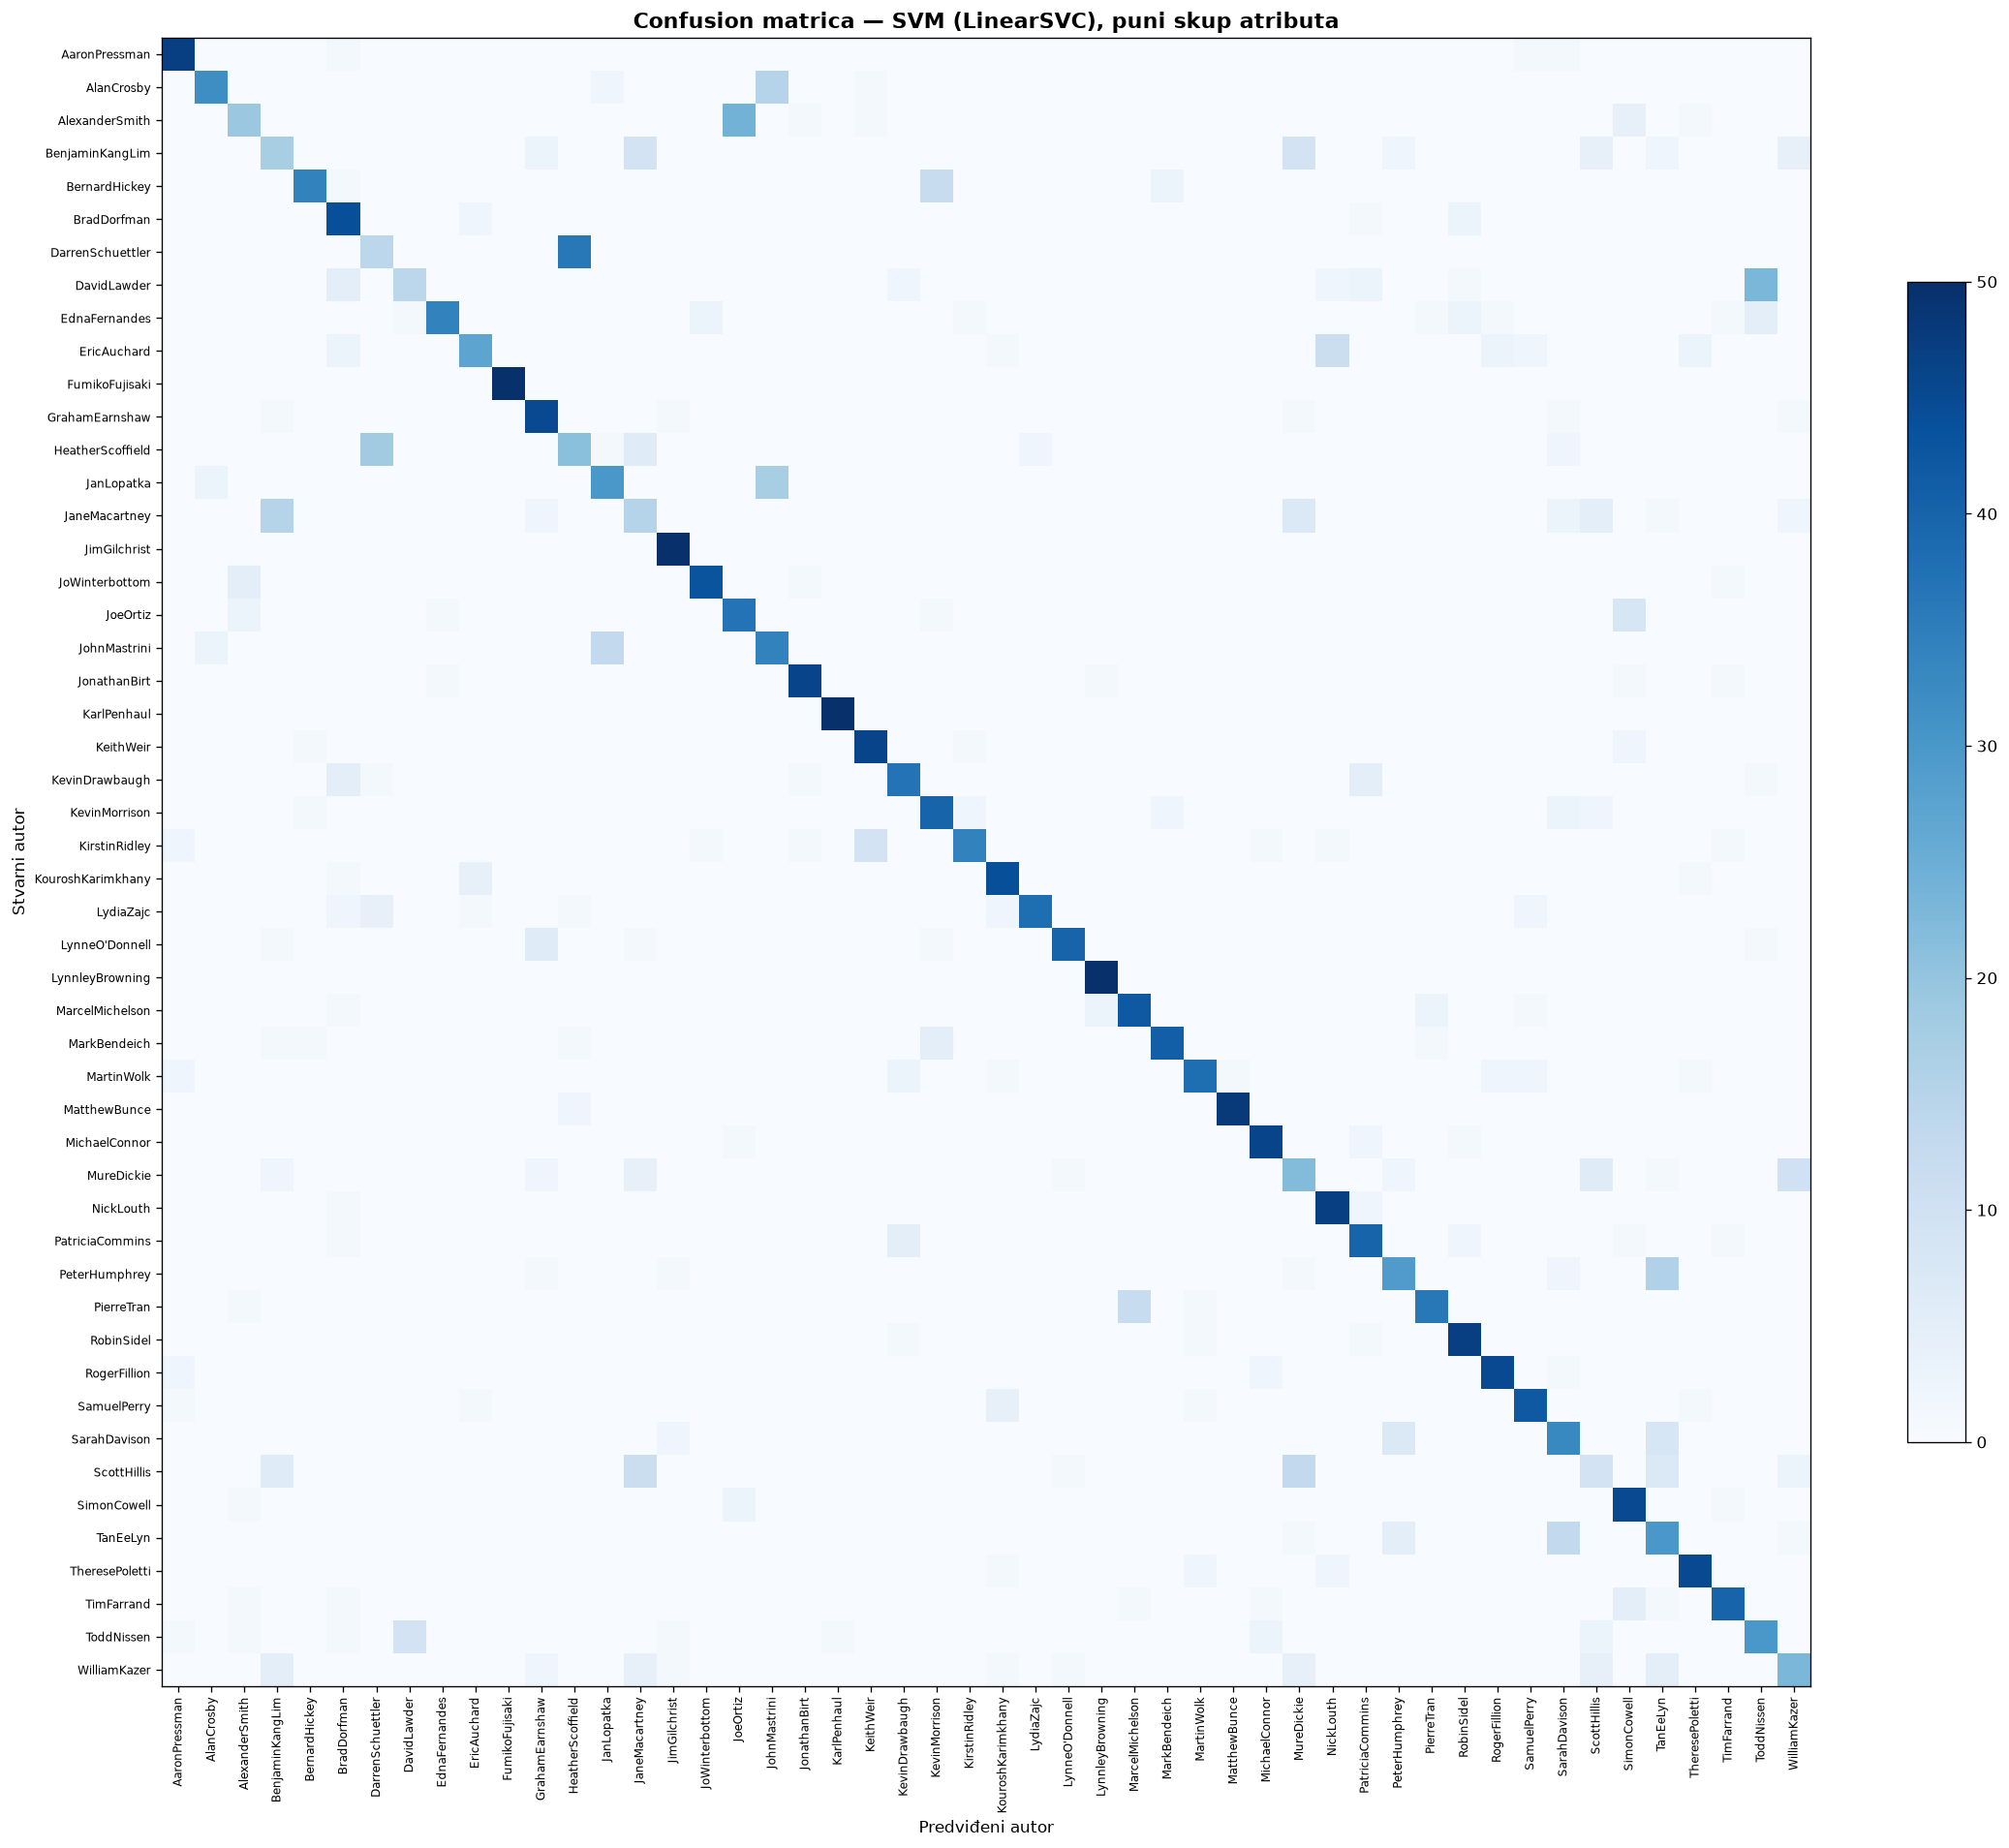


5 najlošije klasifikovanih autora:
ScottHillis         18.0
DarrenSchuettler    28.0
DavidLawder         28.0
JaneMacartney       30.0
BenjaminKangLim     34.0
dtype: float64

5 najbolje klasifikovanih autora:
MatthewBunce        96.0
FumikoFujisaki     100.0
JimGilchrist       100.0
LynnleyBrowning    100.0
KarlPenhaul        100.0
dtype: float64
Slika sacuvana: 15_confusion_matrix.png


In [9]:
cm_mat = confusion_matrix(y_test, y_pred_svm, labels=authors)

fig, ax = plt.subplots(figsize=(18, 16))
im = ax.imshow(cm_mat, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_xticks(range(len(authors)))
ax.set_yticks(range(len(authors)))
ax.set_xticklabels(authors, rotation=90, fontsize=7)
ax.set_yticklabels(authors, fontsize=7)
ax.set_title('Confusion matrica — SVM (LinearSVC), puni skup atributa',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predviđeni autor')
ax.set_ylabel('Stvarni autor')
plt.tight_layout()
plt.savefig(os.path.join(SLIKE_PATH, '15_confusion_matrix.png'))
plt.show()

# Greške po autoru
per_author_acc = cm_mat.diagonal() / cm_mat.sum(axis=1) * 100
acc_series = pd.Series(per_author_acc, index=authors).sort_values()
print('\n5 najlošije klasifikovanih autora:')
print(acc_series.head(5).round(1))
print('\n5 najbolje klasifikovanih autora:')
print(acc_series.tail(5).round(1))
print('Slika sacuvana: 15_confusion_matrix.png')

> **Zaključak:** Confusion matrica vizuelno potvrđuje polarizaciju između autora. Dijagonalni elementi (tačno klasifikovani) su dominantni za većinu autora, ali za **ScottHillis** (18% tačnosti), **DarrenSchuettler** i **DavidLawder** (po 28%) greške su raspršene po više kolona — model ih meša sa više različitih autora. **KarlPenhaul**, **FumikoFujisaki**, **JimGilchrist** i **LynnleyBrowning** imaju 100% recall — svi njihovi dokumenti su tačno prepoznati. Posebno je zanimljivo da FumikoFujisaki (japanski dopisnik) ima i precision 1.0 — ni jedan drugi autor nije greškom klasifikovan kao ona.

### Ćelija 4 - Vizualizacija: F1-score po autoru za top 3 modela

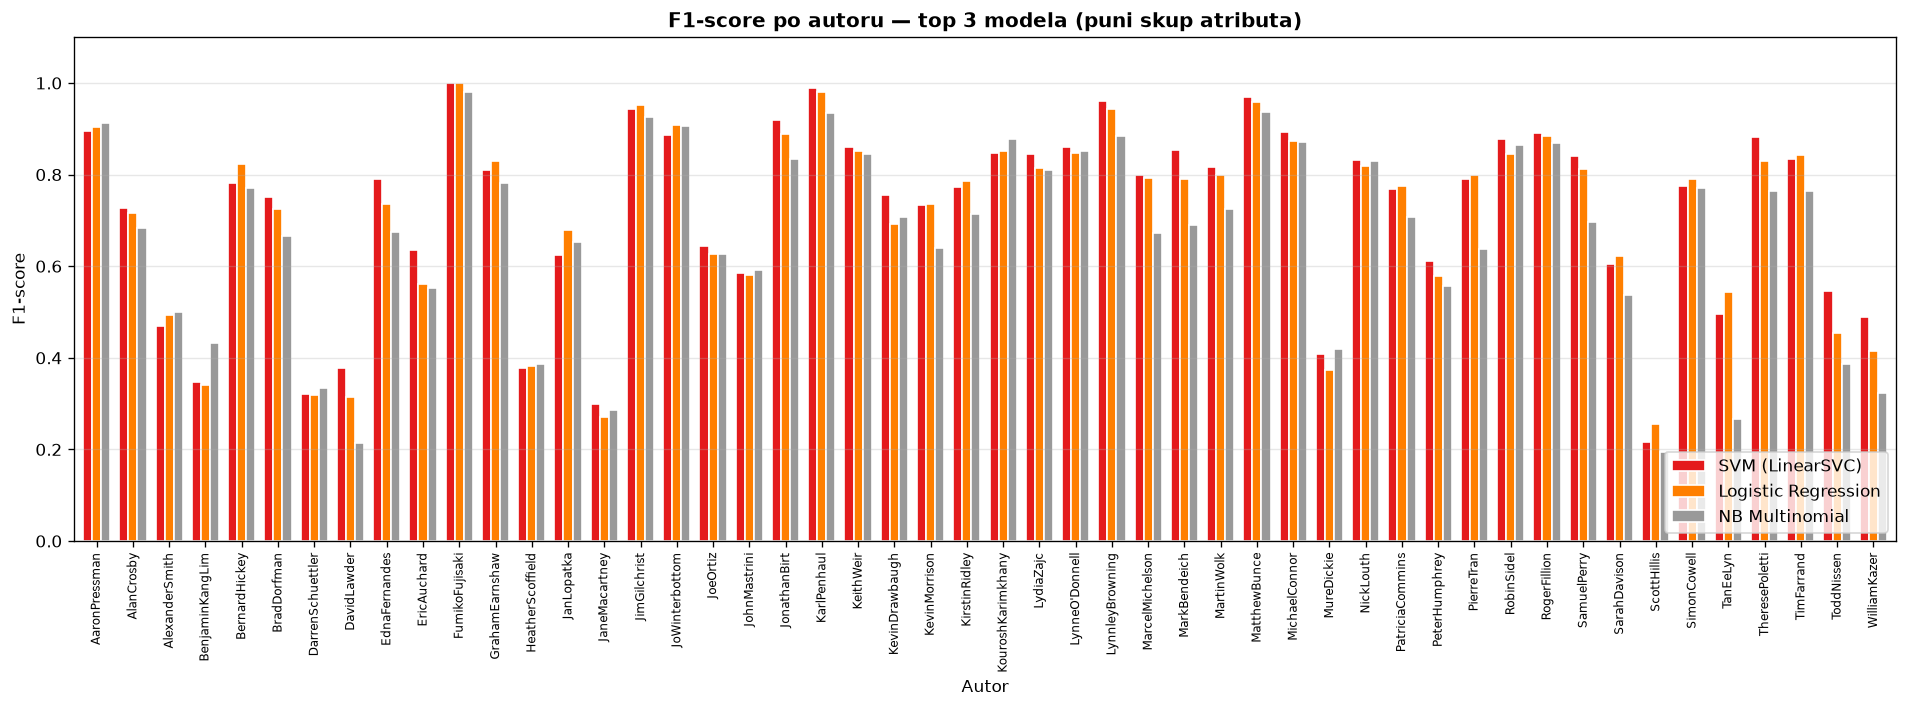

Slika sacuvana: 16_f1_per_author.png

Prosečan F1 po modelu:
SVM (LinearSVC)        0.7203
Logistic Regression    0.7082
NB Multinomial         0.6691
dtype: float64


In [10]:
# Treniramo top 3 modela
top3 = {
    'SVM (LinearSVC)'    : LinearSVC(C=1.0, max_iter=3000, random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(C=5.0, max_iter=1000, solver='lbfgs', random_state=RANDOM_STATE),
    'NB Multinomial'     : MultinomialNB(alpha=0.1)
}

pa_f1 = {}
for name, clf in top3.items():
    clf.fit(X_train, y_train)
    yp = clf.predict(X_test)
    report = classification_report(y_test, yp, target_names=authors, output_dict=True)
    pa_f1[name] = [report[a]['f1-score'] for a in authors]

pa_df = pd.DataFrame(pa_f1, index=authors)

fig, ax = plt.subplots(figsize=(16, 6))
pa_df.plot(kind='bar', ax=ax, colormap='Set1', edgecolor='white', width=0.75)
ax.set_title('F1-score po autoru — top 3 modela (puni skup atributa)', fontweight='bold')
ax.set_xlabel('Autor')
ax.set_ylabel('F1-score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SLIKE_PATH, '16_f1_per_author.png'))
plt.show()
print('Slika sacuvana: 16_f1_per_author.png')

print('\nProsečan F1 po modelu:')
print(pa_df.mean().round(4))

> **Zaključak:** Sva tri modela pokazuju isti obrazac po autorima — tamo gde je SVM dobar, dobri su i LR i NB, a tamo gde greše, greše svi. Ovo ukazuje da problem nije u izboru algoritma, već u tome da određeni autori pišu stilski previše slično da bi ih i jna koji model lako razlikovao. Prosečni F1: SVM **0.7203** > LR **0.7082** > NB **0.6691**. Razlika između SVM i LR je samo 1.2 pp — oba su linearni modeli i slično se ponašaju na TF-IDF reprezentaciji.

### Ćelija 5 - Najlakši i najteži autori za prepoznavanje

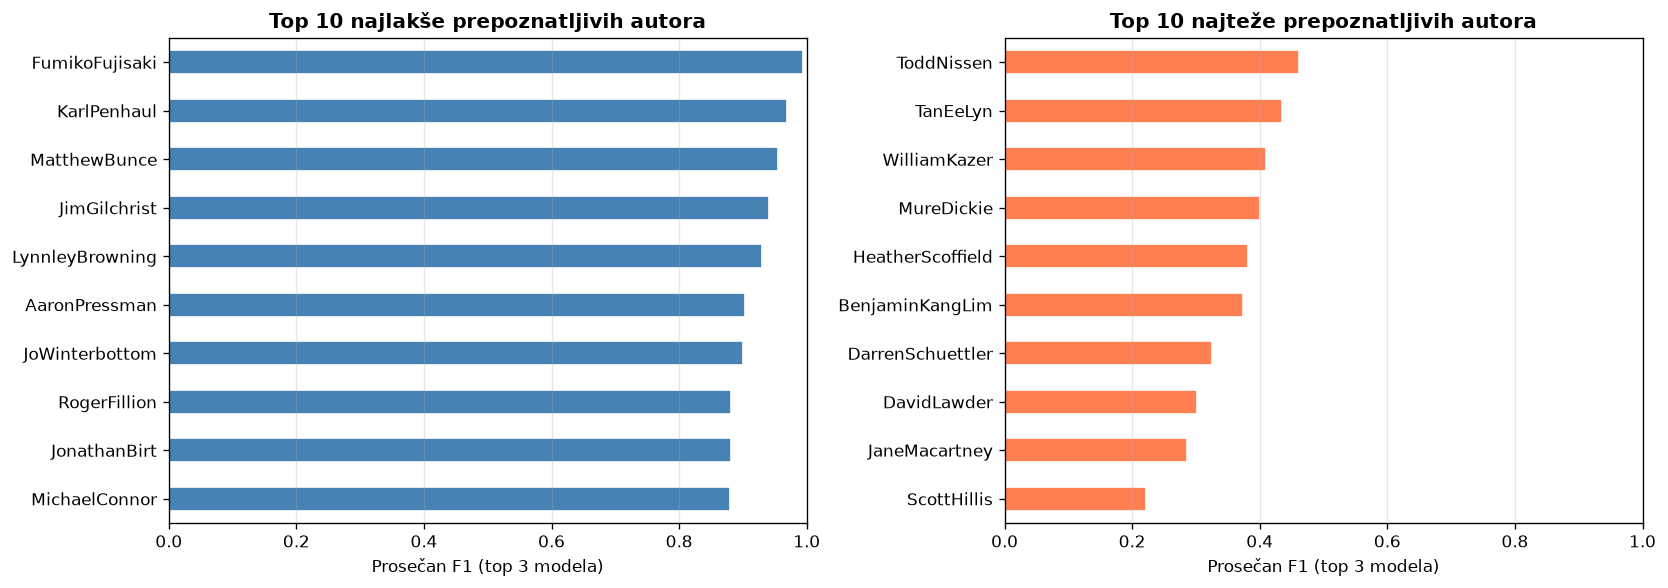

Slika sacuvana: 17_laki_teski_autori.png

Najteži autori (prosečan F1):
ScottHillis         0.222
JaneMacartney       0.286
DavidLawder         0.302
DarrenSchuettler    0.324
BenjaminKangLim     0.373
HeatherScoffield    0.382
MureDickie          0.400
WilliamKazer        0.409
TanEeLyn            0.435
ToddNissen          0.462
dtype: float64

Najlakši autori (prosečan F1):
MichaelConnor      0.879
JonathanBirt       0.881
RogerFillion       0.881
JoWinterbottom     0.900
AaronPressman      0.904
LynnleyBrowning    0.930
JimGilchrist       0.941
MatthewBunce       0.955
KarlPenhaul        0.968
FumikoFujisaki     0.993
dtype: float64


In [11]:
mean_f1 = pa_df.mean(axis=1).sort_values()
hardest = mean_f1.head(10)
easiest = mean_f1.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

easiest.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 najlakše prepoznatljivih autora', fontweight='bold')
axes[0].set_xlabel('Prosečan F1 (top 3 modela)')
axes[0].set_xlim(0, 1)
axes[0].grid(axis='x', alpha=0.3)

hardest.sort_values().plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Top 10 najteže prepoznatljivih autora', fontweight='bold')
axes[1].set_xlabel('Prosečan F1 (top 3 modela)')
axes[1].set_xlim(0, 1)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SLIKE_PATH, '17_laki_teski_autori.png'))
plt.show()
print('Slika sacuvana: 17_laki_teski_autori.png')
print('\nNajteži autori (prosečan F1):')
print(hardest.round(3))
print('\nNajlakši autori (prosečan F1):')
print(easiest.round(3))

> **Zaključak:** **FumikoFujisaki** je najlakši autor za prepoznavanje (F1 = 0.993) — verovatno jer piše isključivo o japanskim temama i koristi specifičan vokabular (japonska vlastita imena, kompanije). **KarlPenhaul** (0.968) i **MatthewBunce** (0.955) su takođe visoko prepoznatljivi. Na drugom kraju, **ScottHillis** (F1 = 0.222) je ubedljivo najteži — svi modeli ga mešaju sa drugim autorima. Grupu teških autora čine uglavnom dopisnici koji pišu o azijskim tržištima (ScottHillis, JaneMacartney, DavidLawder, DarrenSchuettler, BenjaminKangLim, TanEeLyn, WilliamKazer) — oni dele sličan vokabular i tematiku, što ih čini međusobno nerazlučivima.

### Ćelija 6 - 5-Fold Cross-validacija (SVM i LR na punom skupu)

Cross-val: SVM (LinearSVC)... 86.12% ± 1.65%
Cross-val: Logistic Regression... 85.28% ± 1.23%
Cross-val: NB Multinomial... 81.20% ± 2.13%


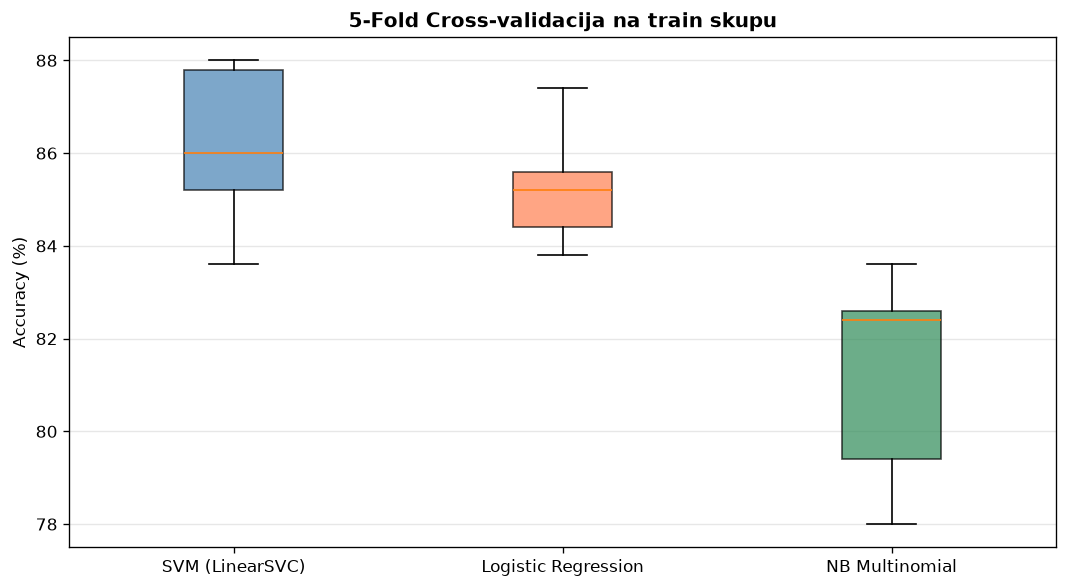

Slika sacuvana: 18_cross_validation.png


In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    'SVM (LinearSVC)'    : LinearSVC(C=1.0, max_iter=3000, random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(C=5.0, max_iter=1000, solver='lbfgs', random_state=RANDOM_STATE),
    'NB Multinomial'     : MultinomialNB(alpha=0.1)
}

cv_results = {}
for name, clf in cv_models.items():
    print(f'Cross-val: {name}...', end=' ', flush=True)
    scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%')

cv_df = pd.DataFrame(cv_results) * 100

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot([cv_df[c].values for c in cv_df.columns],
                tick_labels=cv_df.columns, patch_artist=True, notch=False)
colors_bp = ['steelblue', 'coral', 'seagreen']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('5-Fold Cross-validacija na train skupu', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SLIKE_PATH, '18_cross_validation.png'))
plt.show()
print('Slika sacuvana: 18_cross_validation.png')

> **Zaključak:** Cross-validacija na train skupu daje znatno više rezultate nego na test skupu: SVM **86.12% ± 1.65%**, LR **85.28% ± 1.23%**, NB **81.20% ± 2.13%**. Razlika između CV accuracy (~86%) i test accuracy (~72%) od oko 14 pp ukazuje na određeni stepen overfittinga — modeli se bolje snalaze kada se testiraju unutar train distribucije. Mala standardna devijacija (1.2–2.1%) znači da su modeli stabilni i da rezultat nije slučajan. NB ima najveću varijabilnost (±2.13%), što ga čini manje pouzdanim od SVM i LR koji su stabilniji kroz sve foldove.

### Ćelija 7 - Najvažnije reči po autoru (SVM koeficijenti)

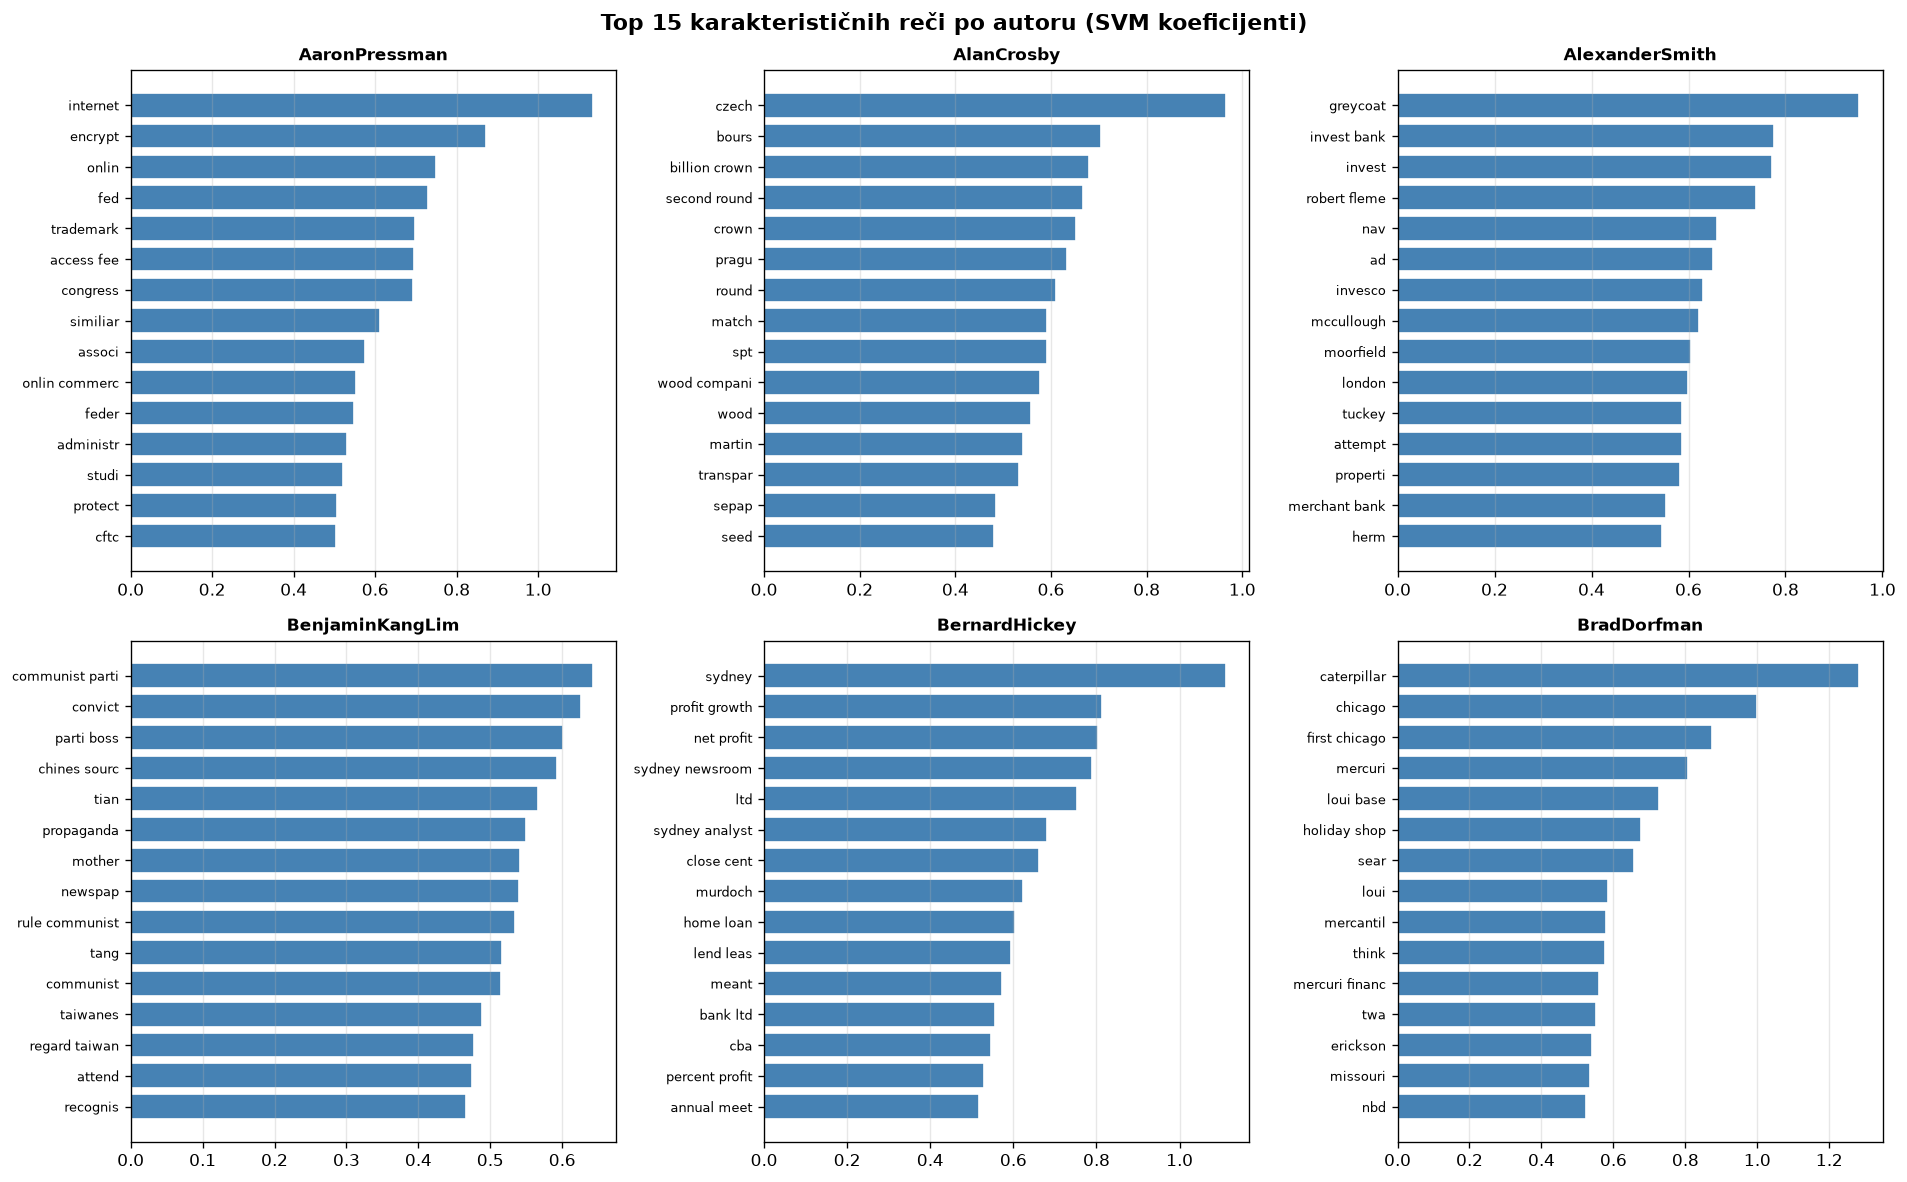

Slika sacuvana: 19_top_reci_svm.png


In [13]:
feature_names = np.array(tfidf.get_feature_names_out())

# Vizualizacija za prvih 6 autora
sel_authors = authors[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, author in enumerate(sel_authors):
    class_idx = list(svm.classes_).index(author)
    top_idx   = np.argsort(svm.coef_[class_idx])[-15:]
    top_words = feature_names[top_idx]
    top_coefs = svm.coef_[class_idx][top_idx]
    axes[idx].barh(top_words, top_coefs, color='steelblue', edgecolor='white')
    axes[idx].set_title(author, fontweight='bold', fontsize=10)
    axes[idx].grid(axis='x', alpha=0.3)
    axes[idx].tick_params(axis='y', labelsize=8)

plt.suptitle('Top 15 karakterističnih reči po autoru (SVM koeficijenti)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SLIKE_PATH, '19_top_reci_svm.png'))
plt.show()
print('Slika sacuvana: 19_top_reci_svm.png')

> **Zaključak:** SVM koeficijenti otkrivaju koje reči model smatra najkarakterističnijim za svakog autora. **AaronPressman** se prepoznaje po rečima vezanim za internet i sajber-bezbednost (fraud, internet, cyberspace), što odgovara temama koje pokriva. **BenjaminKangLim** koristi specifičan azijski vokabular (China, Hong Kong, Beijing), što objašnjava njegovu sličnost sa drugim azijskim dopisnicima i posledično lošu klasifikacionu tačnost. Autori sa jedinstvenim temama (KarlPenhaul — ratni izveštač, FumikoFujisaki — Japan) imaju visoko specifične top reči koje se ne pojavljuju kod других autora, što direktno korelira sa njihovim visokim F1 skorovima.

### Ćelija 8 - Finalni bar chart: poređenje svih modela (puni skup)

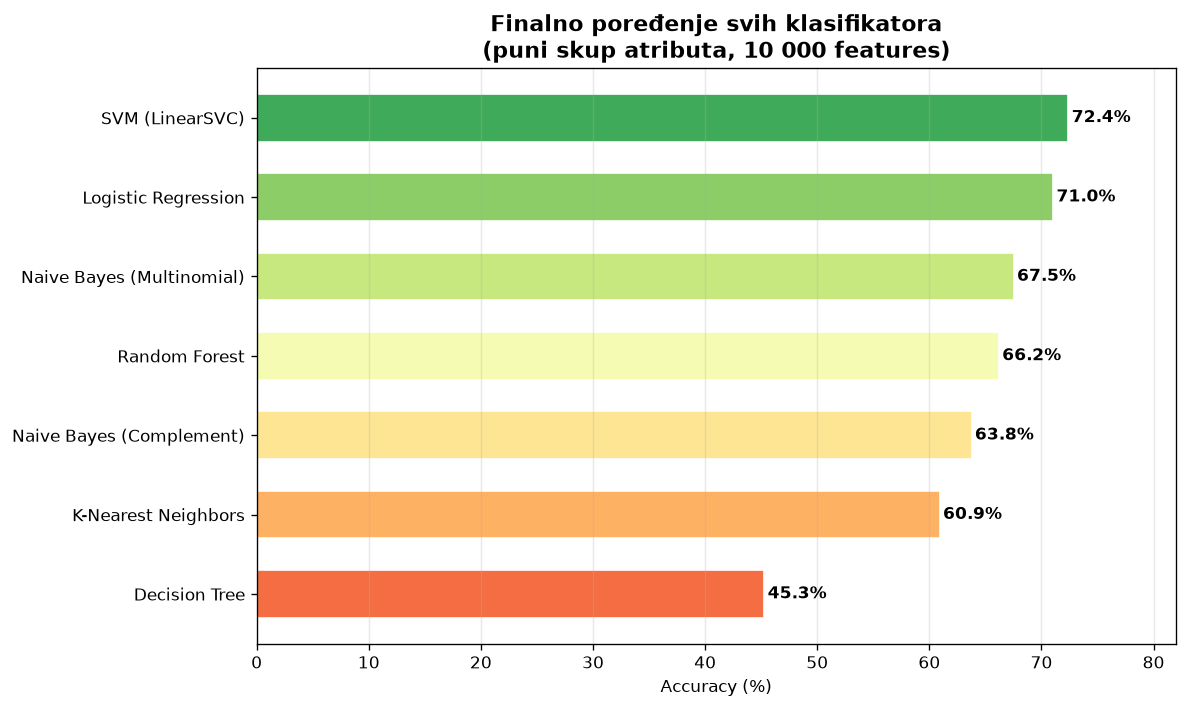

Slika sacuvana: 20_finalno_poredenje.png

Sve slike u /slike folderu:
  01_distribucija_autora.png
  02_distribucija_duzine.png
  03_boxplot_duzine.png
  04_efekat_preprocesiranja.png
  05_top20_reci_pre_posle.png
  06_wordcloud.png
  07_svd_scree.png
  08_pca_2d.png
  09_pca_3d.png
  10_tsne_2d.png
  11_pca_vs_tsne.png
  12_accuracy_bar.png
  13_heatmap_metrike.png
  14_efekat_broja_atributa.png
  15_confusion_matrix.png
  16_f1_per_author.png
  17_laki_teski_autori.png
  18_cross_validation.png
  19_top_reci_svm.png
  20_finalno_poredenje.png


In [14]:
results_df = pd.read_csv('/home/zagorka/Desktop/ip2Projekat/rezultati_klasifikacije.csv')
full_df = results_df[results_df['Skup atributa']=='Puni (10000)'].sort_values('Accuracy')

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(full_df)))
bars = ax.barh(full_df['Klasifikator'], full_df['Accuracy'],
               color=bar_colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, full_df['Accuracy']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)
ax.set_title('Finalno poređenje svih klasifikatora\n(puni skup atributa, 10 000 features)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Accuracy (%)')
ax.set_xlim(0, 82)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SLIKE_PATH, '20_finalno_poredenje.png'))
plt.show()
print('Slika sacuvana: 20_finalno_poredenje.png')
print()
print('Sve slike u /slike folderu:')
for f in sorted(os.listdir(SLIKE_PATH)):
    print(f'  {f}')

> **Zaključak:** Finalni bar chart potvrđuje jasnu hijerarhiju modela na punom skupu atributa. **SVM (72.4%)** i **Logistička regresija (71.0%)** dominiraju kao dva linearna modela pogodna za TF-IDF reprezentaciju. **Naive Bayes Multinomial (67.5%)** dolazi treći uprkos jednostavnosti pretpostavki o nezavisnosti atributa. **Random Forest (66.2%)** je iznenađujuće dobar s obzirom na visoku dimenzionalnost, ali zaostaje za linearnim modelima. **KNN (60.9%)** je ograničen tačnošću kosinusne metrike u 10 000-dimenzionalnom prostoru. **Decision Tree (45.3%)** je najlošiji — stabla odluke loše generalizuju na retkim visoko-dimenzionalnim matricama. Svih 20 slika je sačuvano u folderu slike/, a projekat je spreman za dokumentaciju.